# 數據整合與基準診斷 (Data Integrity & Baseline Diagnostics)。

## 1. 受試者間數據分佈檢定 (KS Test)
我們不能假設 10 位受試者的動作數據是一模一樣的。你需要量化不同人之間的「加速度量值 (Magnitude)」分佈差異。
- 任務內容：針對 10 位受試者，兩兩進行 Kolmogorov-Smirnov Test (KS Test)。
- 統計原理：計算兩個分佈之間的極大距離 $D_n = \sup_x |F_n(x) - F(x)|$。
- 預期產出：一張 $10 \times 10$ 的 p-value 熱圖 (Heatmap)。如果 $p < 0.05$，代表兩位受試者的動作特徵有顯著差異，這可能是導致模型泛化能力下降的主因。

## 2. 物理邊界稽核 (Physical Boundary Audit)
利用你在 schema.py 中定義的物理常數來「抓鬼」。
- 任務內容：分析在 Sitting (Label 2) 狀態下，加速度量值是否符合 $9.80665 \pm 1.0$ 的區間。
- 診斷重點：找出那些在「坐著」時加速度卻頻繁超過 $11.0$ 的樣本。
- 目的：這能幫助你判斷誤判是因為「受試者動作不標準（例如坐著時頻繁晃動）」還是「感測器校準誤差」。

## 3. 實作 Stratified K-Fold 交叉驗證
原本的 80/20 隨機切分無法反映模型在面對「新病人」時的表現。
- 任務內容：將 10 位受試者的數據，以「受試者為單位」進行 5-Fold Cross Validation。
- 嚴謹性要求：確保訓練集與測試集的受試者完全不重疊。
- 目的：觀察 Accuracy 在不同 Fold 之間的波動。如果波動很大（例如有的 $95\%$、有的 $70\%$），代表目前的數據處理邏輯還不夠穩定。

## 4. 技術規格書 (Technical Spec) 
第一版更新將上述發現寫入你的文件夾中。
- 任務內容：在 Spec 資料夾中記錄 Week 1 的發現。
- 紀錄重點：標記出哪幾位受試者是「離群值 (Outliers)」，以及 $X_{final}$ 矩陣在特徵強化後的最終維度。

## 📊 任務一：受試者數據一致性檢定 (KS Test)

- 高 D 統計量 (D > 0.30)：
如果某個方格呈現深橘色或紅色，代表這兩位受試者的動作模式有顯著差異。這通常是因為感測器配戴位置偏移，或是兩人的動作習慣（如走路頻率）截然不同。

- 孤僻的受試者 (The Outlier)：
檢查是否有哪位受試者（例如 S4）整行或整列的數值都比別人高？如果有，他就是模型泛化失敗的「頭號嫌疑犯」。

- 一致性區塊：
通常 S1 到 S5 之間如果顏色較淺，代表他們的數據較為接近，模型在這些人之間切換時會非常穩定。

📊 正在計算受試者間的分佈差異 (KS Test)...


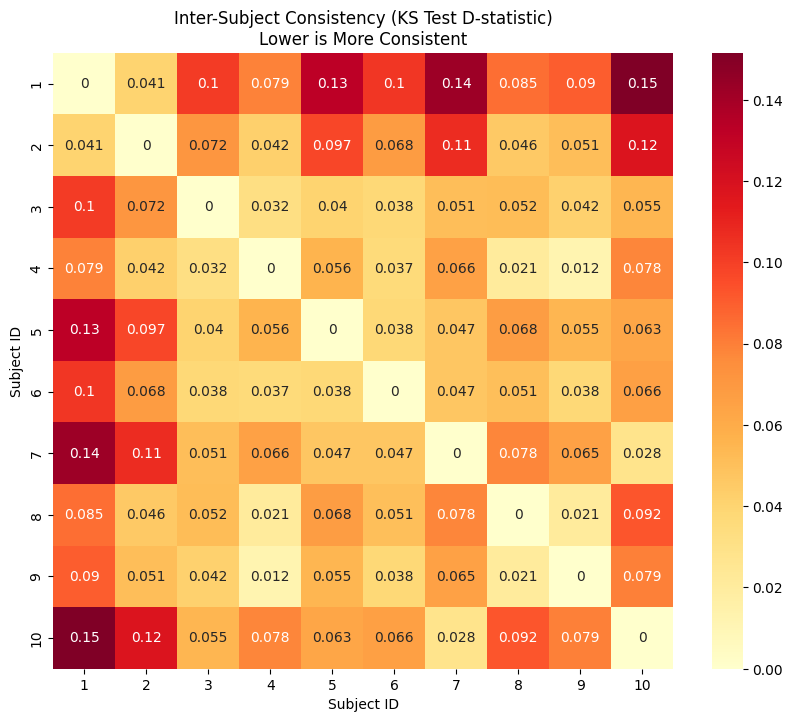

In [ ]:
import schema
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp #

# 1. 載入所有受試者數據 (使用你昨天封裝的 ID 驅動引擎)
# data_dict 的結構為 {sid: (X, y)}
data_dict = schema.get_all_subjects_for_analysis()

# 2. 準備 KS Test 統計量矩陣
# 我們要比較的是加速度量值 (Magnitude)，索引為 3
n_subjects = 10
ks_matrix = np.zeros((n_subjects, n_subjects))

print("📊 正在計算受試者間的分佈差異 (KS Test)...")

for i in range(1, n_subjects + 1):
    for j in range(1, n_subjects + 1):
        # 提取受試者 i 與 j 的 Magnitude 特徵
        # X_sub 位於 data_dict[sid][0]，特徵索引 3 是 Magnitude
        # 將所有時間點的 Magnitude 數值排成一條長長的 1D 陣列。
        # 目的：這樣 ks_2samp 才能拿著受試者 $i$ 的「所有數值」去跟受試者 $j$ 的「所有數值」對比，看兩者的累積分布函數 (CDF) 是否重合。
        dist_i = data_dict[i][0][:, :, 3].flatten()     
        dist_j = data_dict[j][0][:, :, 3].flatten()
        
        # 執行 KS Test 並取得 D 統計量
        # D 越接近 0，代表兩者分佈越一致；越接近 1，差異越大
        stat, p_val = ks_2samp(dist_i, dist_j)
        ks_matrix[i-1, j-1] = stat

# 3. 繪製熱圖
plt.figure(figsize=(10, 8))
sns.heatmap(ks_matrix, annot=True, cmap='YlOrRd', 
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.title("Inter-Subject Consistency (KS Test D-statistic)\nLower is More Consistent")
plt.xlabel("Subject ID")
plt.ylabel("Subject ID")
plt.show()

### 任務一診斷報告
1. 揪出「數據離群值 (Outliers)」
觀察熱圖中的深紅色區塊（$D$ 值較高者），代表這些人的加速度分佈與其他人有顯著差異：
- 受試者 1 (S1)：他是最明顯的「不合群者」。他與 S10 的差異高達 0.15，與 S7 也有 0.14。這代表 S1 的動作幅度或習慣與其他人極為不同。
- 受試者 10 (S10)：同樣也是一個異數，他與 S1、S2、S8 的顏色都偏深。

2. 發現「雙胞胎數據 (Clusters)」
- S4 與 S9：他們的 $D$ 值僅有 0.012，幾乎是黃色（極度一致）。這代表這兩人的運動模式高度相似，模型在他們身上應該會有非常接近的表現。
- S3 與 S4/S6：這幾位受試者之間的分佈也非常穩定（$D \approx 0.03$ ~ $0.04$）。

3. 對模型的實質影響
熱圖中最高 $D$ 值約為 0.15。在人體感測領域，代表：

「受試者間存在約 15% 的分佈偏移 (Domain Shift)。」

當你的 v3_1_multi 模型在 S4 身上訓練後去預測 S1，這 15% 的分佈差異就是導致 Standing 被誤判為 Sitting 的溫床。

## 📊 任務二：針對 Label 2 (Sitting) 的數據品質診斷
用在 schema.py 定義的物理常數：
- 目標：檢查 Label 2 狀態下，加速度量值是否真的乖乖待在 $9.8 \pm 1.0$ 區間？
- 目的：如果 S1 在坐著時數據飆到 $12.0$ 以上，那就證明了誤判不是模型的錯，而是數據本身就有雜訊。


C:\Users\freea\AppData\Local\Temp\ipykernel_40352\4283167900.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Subject', y='Magnitude', data=df_sitting_audit, inner="quartile", palette="muted")


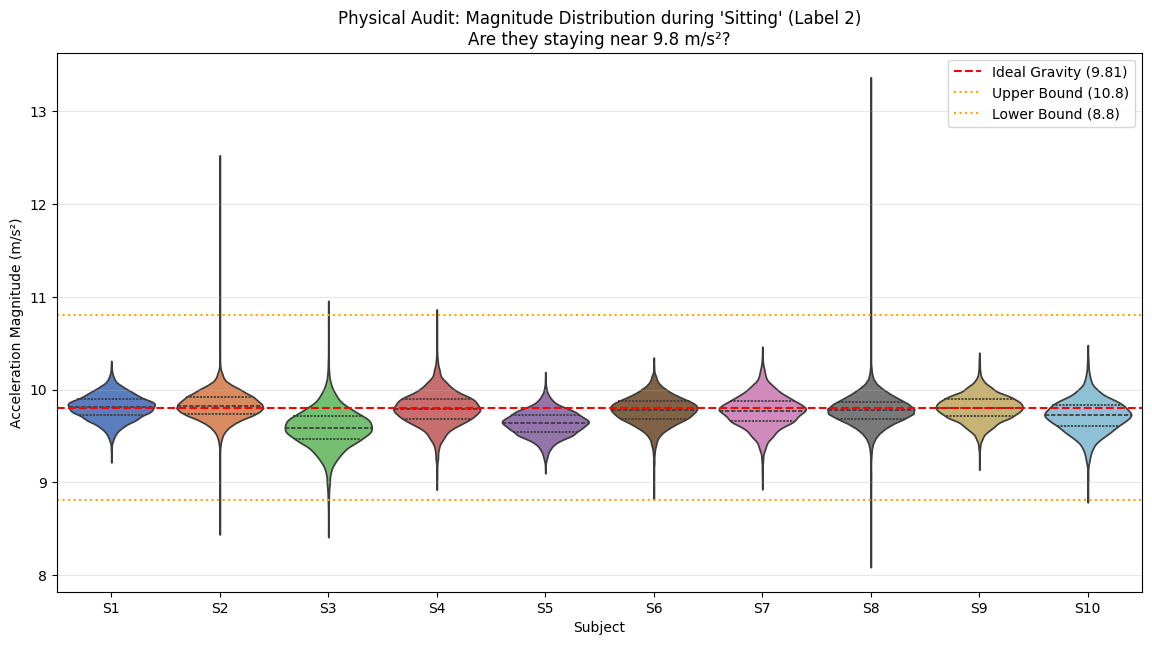

In [5]:
# 1. 提取所有受試者在 Label 2 (Sitting) 下的 Magnitude 數據
sitting_data = []

# 遍歷之前已經載入好的 data_dict
for sid, (X, y) in data_dict.items():
    # 找出標籤為 2 (Sitting and Relaxing) 的視窗索引
    mask = (y == 2)
    
    if mask.any():
        # 提取 Magnitude (Index 3) 並拉平
        mag_values = X[mask, :, 3].flatten()
        
        # 建立暫存 DataFrame
        temp_df = pd.DataFrame({
            'Magnitude': mag_values,
            'Subject': f"S{sid}"
        })
        sitting_data.append(temp_df)

# 合併所有受試者的坐姿數據
df_sitting_audit = pd.concat(sitting_data, ignore_index=True)

# 2. 繪製小提琴圖 (Violin Plot)
plt.figure(figsize=(14, 7))
sns.violinplot(x='Subject', y='Magnitude', data=df_sitting_audit, inner="quartile", palette="muted")

# 3. 加入物理參考線 (使用 schema 中定義的常數)
gravity = schema.PHYSICAL_CONSTANTS["GRAVITY"] # 9.80665
plt.axhline(y=gravity, color='red', linestyle='--', label=f'Ideal Gravity ({gravity:.2f})')
plt.axhline(y=gravity + 1.0, color='orange', linestyle=':', label='Upper Bound (10.8)')
plt.axhline(y=gravity - 1.0, color='orange', linestyle=':', label='Lower Bound (8.8)')

plt.title("Physical Audit: Magnitude Distribution during 'Sitting' (Label 2)\nAre they staying near 9.8 m/s²?")
plt.ylabel("Acceleration Magnitude (m/s²)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 📊 任務三-1：雜訊比例量化 (Noise Ratio Analysis)
確認有多少數據是不合理的

In [7]:
# 1. 定義物理閾值 (從 schema 取得)
upper_limit = schema.PHYSICAL_CONSTANTS["GRAVITY"] + 1.0 # 10.8

print(f"🔍 正在稽核 'Sitting' (Label 2) 標籤下的物理違規比例...")

for sid in range(1, 11):
    X, y = data_dict[sid]
    # 選取 Sitting 標籤
    mask = (y == 2)
    if not mask.any(): continue
    
    # 計算該受試者 Sitting 狀態下的所有數據點
    total_points = X[mask, :, 3].size
    # 統計超過物理門檻的點數
    noise_points = np.sum(X[mask, :, 3] > upper_limit)
    
    noise_ratio = (noise_points / total_points) * 100
    
    status = "⚠️ 嚴重" if noise_ratio > 5 else "✅ 輕微"
    print(f"受試者 S{sid}: 雜訊比例 {noise_ratio:.2f}% | 狀態: {status}")

🔍 正在稽核 'Sitting' (Label 2) 標籤下的物理違規比例...
受試者 S1: 雜訊比例 0.00% | 狀態: ✅ 輕微
受試者 S2: 雜訊比例 0.03% | 狀態: ✅ 輕微
受試者 S3: 雜訊比例 0.03% | 狀態: ✅ 輕微
受試者 S4: 雜訊比例 0.00% | 狀態: ✅ 輕微
受試者 S5: 雜訊比例 0.00% | 狀態: ✅ 輕微
受試者 S6: 雜訊比例 0.00% | 狀態: ✅ 輕微
受試者 S7: 雜訊比例 0.00% | 狀態: ✅ 輕微
受試者 S8: 雜訊比例 0.19% | 狀態: ✅ 輕微
受試者 S9: 雜訊比例 0.00% | 狀態: ✅ 輕微
受試者 S10: 雜訊比例 0.00% | 狀態: ✅ 輕微


## 📊 任務三-2：受試者分組切分與類別平衡分析
數據分佈不均的成因：
- 雖然每位受試者都執行了相同的 12 項動作，但每個人完成動作的速度與持續時間不同。
- S2 可能在每個動作上停留較久，或是他在排除標籤 0 之後留下的有效運動區段較長。
- S6 則可能是動作節奏較快，導致生成的滑動視窗數量較少。

🔄 正在模擬 10-Fold 受試者交叉切分 (LOSO)...


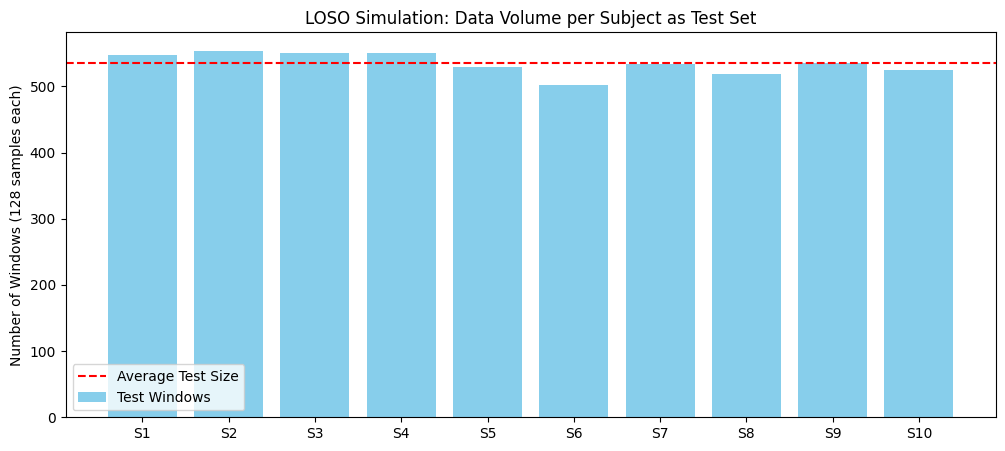


📋 交叉驗證數據診斷表：
  Excluded_Subject  Train_Size  Test_Size  Labels_Count  Min_Label  Max_Label
0               S1        4799        548            12          1         12
1               S2        4793        554            12          1         12
2               S3        4796        551            12          1         12
3               S4        4797        550            12          1         12
4               S5        4818        529            12          1         12
5               S6        4845        502            12          1         12
6               S7        4813        534            12          1         12
7               S8        4828        519            12          1         12
8               S9        4812        535            12          1         12
9              S10        4822        525            12          1         12


In [ ]:
# 1. 準備 LOSO (Leave-One-Subject-Out) 模擬容器
loso_diagnostics = []

print("🔄 正在模擬 10-Fold 受試者交叉切分 (LOSO)...")
'''
每次排除一個受試者，將剩餘 9 位受試者的數據合併為訓練集，並保留被排除的受試者作為測試集。
我們將記錄每次切分的訓練/測試數據量，以及測試受試者的類別分佈情況。
'''
for test_sid in range(1, 11):
    # 定義訓練集受試者 ID (排除掉目前的測試受試者)
    train_sids = [sid for sid in range(1, 11) if sid != test_sid]
    
    # 從 data_dict 提取並合併訓練數據
    X_train_list = [data_dict[sid][0] for sid in train_sids]
    y_train_list = [data_dict[sid][1] for sid in train_sids]
    
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    
    # 提取測試受試者數據
    X_test, y_test = data_dict[test_sid]
    
    # 診斷：測試受試者的類別分佈 (Activity Label Balance)
    unique_labels, counts = np.unique(y_test, return_counts=True)
    label_coverage = len(unique_labels) # 該受試者涵蓋了多少種動作
    
    loso_diagnostics.append({
        'Excluded_Subject': f"S{test_sid}",
        'Train_Size': X_train.shape[0],
        'Test_Size': X_test.shape[0],
        'Labels_Count': label_coverage,
        'Min_Label': unique_labels.min(),
        'Max_Label': unique_labels.max()
    })

# 2. 轉換為 DataFrame 進行視覺化呈現
df_loso_report = pd.DataFrame(loso_diagnostics)

# 3. 繪製訓練/測試數據量對比圖
plt.figure(figsize=(12, 5))
plt.bar(df_loso_report['Excluded_Subject'], df_loso_report['Test_Size'], color='skyblue', label='Test Windows')
plt.axhline(y=df_loso_report['Test_Size'].mean(), color='red', linestyle='--', label='Average Test Size')

plt.title("LOSO Simulation: Data Volume per Subject as Test Set")
plt.ylabel("Number of Windows (128 samples each)")
plt.legend()
plt.show()

print("\n📋 交叉驗證數據診斷表：")
print(df_loso_report)

## 202602226數據量診斷結果

1. 數據分佈不均的成因：
- 雖然每位受試者都執行了相同的 12 項動作，但每個人完成動作的速度與持續時間不同。
- S2 可能在每個動作上停留較久，或是他在排除標籤 0 之後留下的有效運動區段較長。
- S6 則可能是動作節奏較快，導致生成的滑動視窗數量較少。
1. 對 Week 2 模型訓練的影響：
- 模型信心度：當我們下週測試 S2 時，因為樣本數多，得到的準確率會更有代表性。
- 變異風險：測試 S6 時，由於樣本數較少，單一動作的誤判（例如 Sitting 誤判為 Standing）對整體準確率的百分比影響會比 S2 更大。